In [2]:
import pandas as pd
import numpy as np
from sklearn.datasets import load_iris


In [3]:
iris= load_iris()


In [4]:
df= pd.DataFrame(iris['data'], columns= iris.feature_names)
df['target']= iris.target

In [5]:
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [6]:
print(iris.target_names)

['setosa' 'versicolor' 'virginica']


In [7]:
#df['target']= df['target'].map(dict(enumerate(iris.target_names))), another way of mapping the values of output column

<Axes: xlabel='count', ylabel='target'>

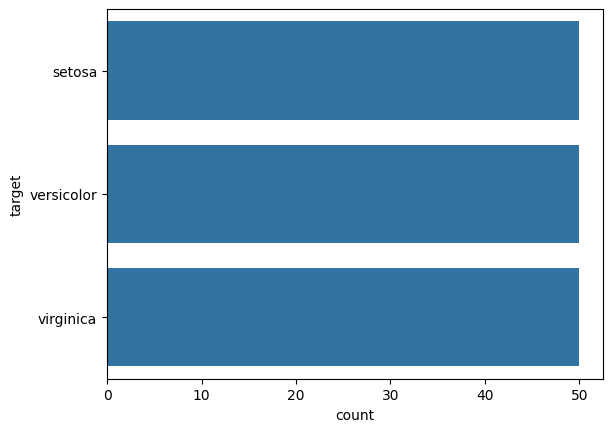

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(df['target'].map(dict(enumerate(iris.target_names))))

In [9]:
df['target'].value_counts()

target
0    50
1    50
2    50
Name: count, dtype: int64

In [10]:
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [11]:
x= df.iloc[:, 0:-1]
y= df.iloc[:, -1]

In [12]:
from sklearn.model_selection import train_test_split, GridSearchCV
x_train, x_test, y_train, y_test= train_test_split(x, y, random_state= 42)

In [13]:
from sklearn.tree import DecisionTreeClassifier
model= DecisionTreeClassifier()




In [14]:
model.__dict__

{'criterion': 'gini',
 'splitter': 'best',
 'max_depth': None,
 'min_samples_split': 2,
 'min_samples_leaf': 1,
 'min_weight_fraction_leaf': 0.0,
 'max_features': None,
 'max_leaf_nodes': None,
 'random_state': None,
 'min_impurity_decrease': 0.0,
 'class_weight': None,
 'ccp_alpha': 0.0,
 'monotonic_cst': None}

In [ ]:
param_grid= {
    'criterion': ['gini', 'entropy'],
    'splitter': ['best', 'random'],
    'max_depth': [x for x in range(1, 21)] + [None],
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf': [1, 2, 4, 8],
    'max_features': [1,2,3,4],

}

In [ ]:
params= GridSearchCV(
    estimator=model,
    param_grid= param_grid,
    scoring= 'accuracy',
    n_jobs= -1,
    
)

In [17]:
params.fit(x_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",DecisionTreeClassifier()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'criterion': ['gini', 'entropy'], 'max_depth': [1, 2, ...], 'max_features': [1, 2, ...], 'min_samples_leaf': [1, 2, ...], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",None
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and pa

In [18]:
params.best_params_

{'criterion': 'gini',
 'max_depth': 7,
 'max_features': 3,
 'min_samples_leaf': 4,
 'min_samples_split': 5,
 'splitter': 'random'}

In [19]:
params.best_score_

np.float64(0.9731225296442687)

In [20]:
model= DecisionTreeClassifier(**params.best_params_)

In [21]:
model.fit(x_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'random'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",7
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",5
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",4
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",3
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current n

In [22]:
y_pred= model.predict(x_test)

In [23]:
from sklearn.metrics import confusion_matrix, accuracy_score

print(confusion_matrix(y_true= y_test, y_pred= y_pred))

[[15  0  0]
 [ 0 11  0]
 [ 0  0 12]]


In [24]:
print(accuracy_score(y_test, y_pred))

1.0


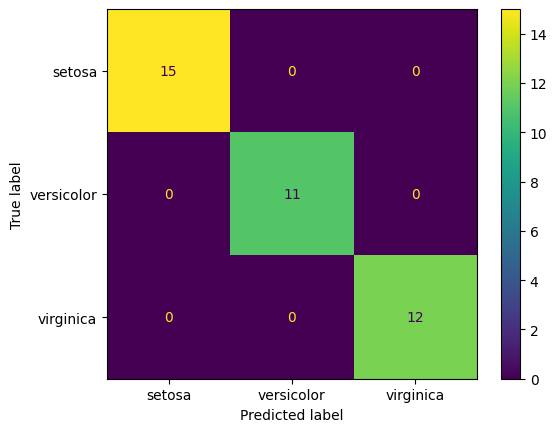

In [25]:
from sklearn.metrics import ConfusionMatrixDisplay
ConfusionMatrixDisplay.from_predictions(y_true= y_test, y_pred= y_pred, display_labels= iris.target_names)
plt.show()


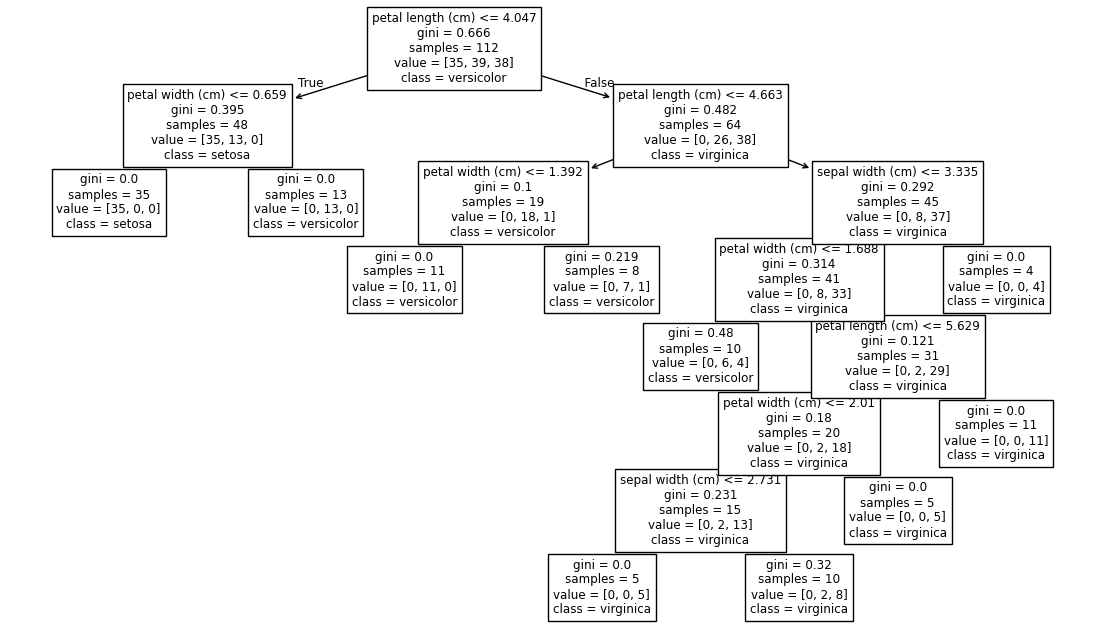

In [26]:
from sklearn.tree import plot_tree
plt.figure(figsize=(14,8))
plot_tree(
    model,
    feature_names= df.columns[:-1],
    #class_names= df['target'].unique()
    class_names= iris.target_names
)
plt.show()

In [27]:
import dtreeviz

# for dtreeviz, y column must be labeled one. 

In [28]:
viz= dtreeviz.model(
     model,
    x_train,
    y_train,
    feature_names= list(df.columns[:-1]),
    target_name= 'target',
    class_names= iris.target_names
)
   



c:\Users\Yunish\miniconda3\envs\myenv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names


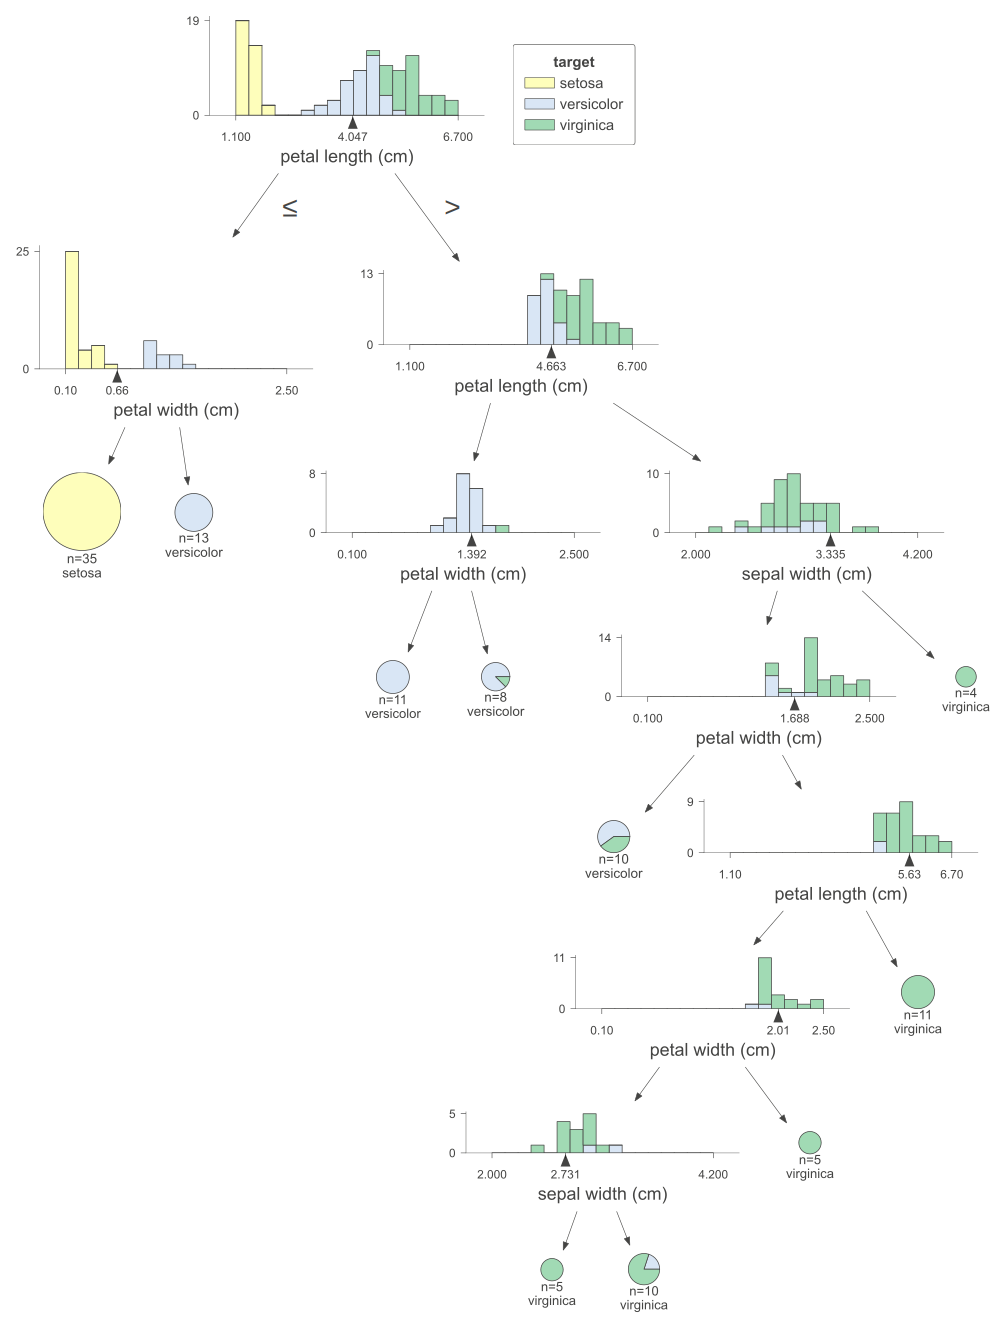

In [29]:
viz.view(scale= 2)

In [30]:
x_sample= df.sample(1).values
x_sample= x_sample.ravel()   #converting into 1d
x_sample= x_sample[:-1]  #removing the target value

x_sample

array([5.8, 2.7, 3.9, 1.2])

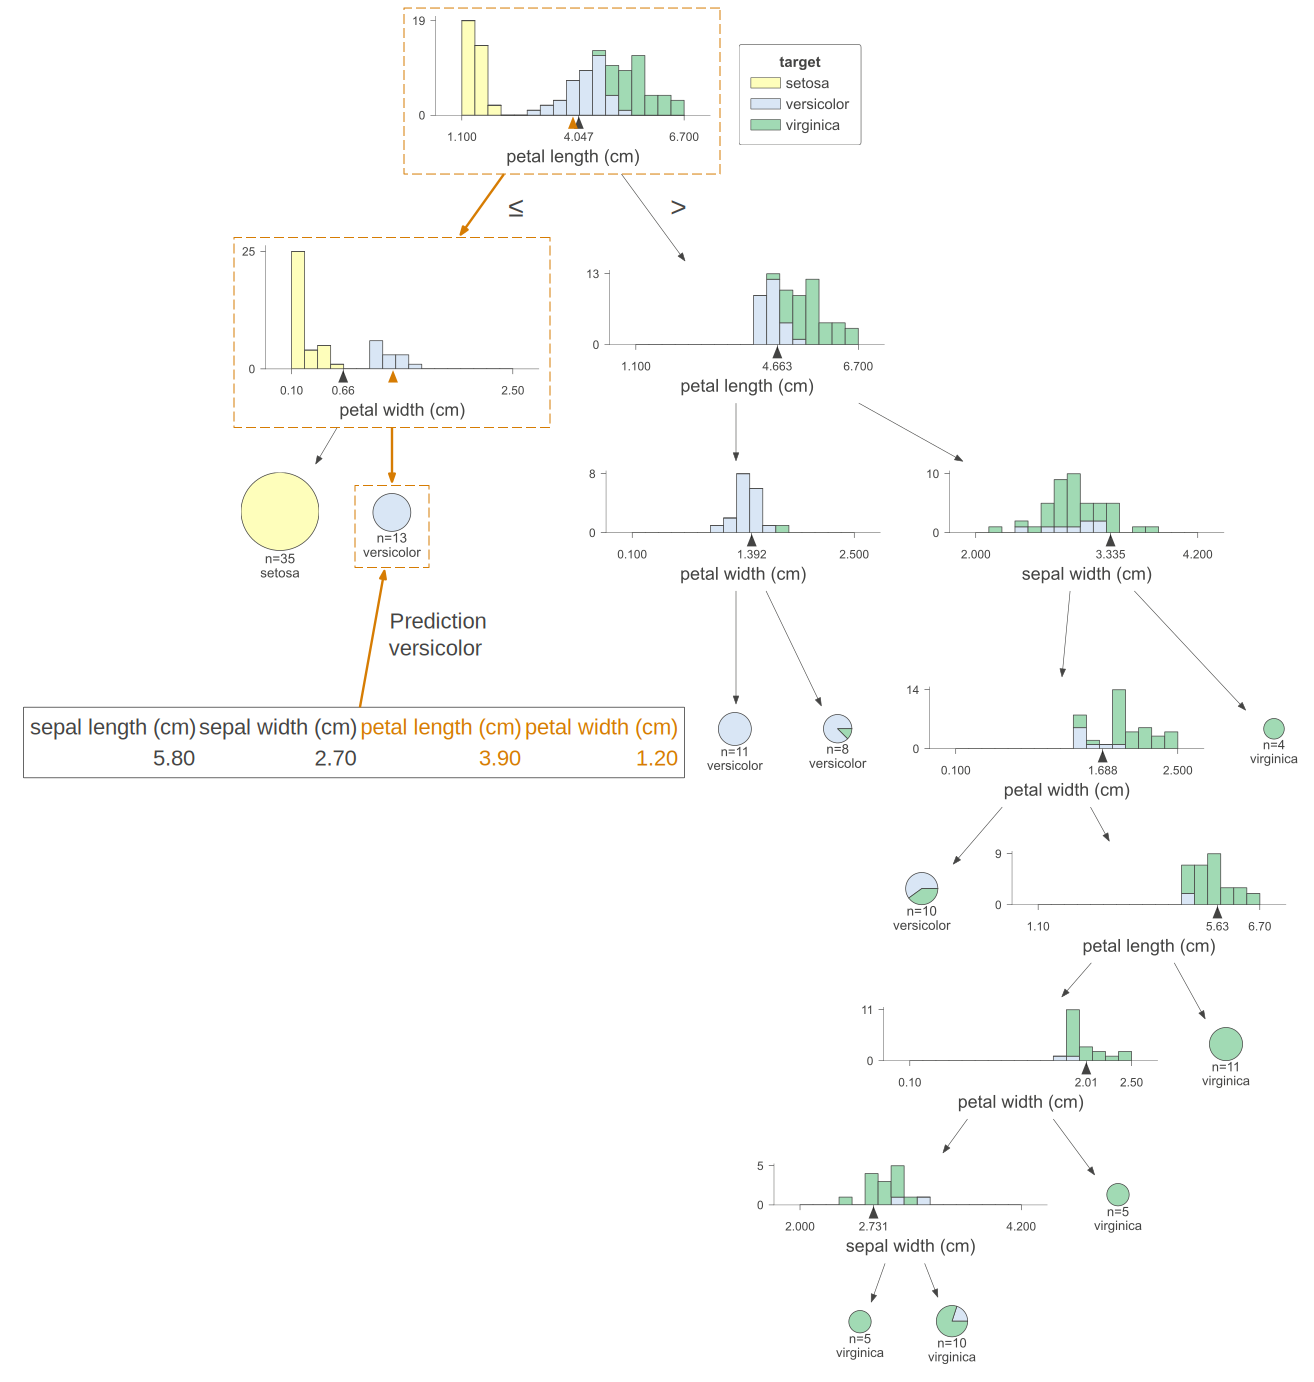

In [55]:
viz.view(x= x_sample, scale= 2)

In [32]:
model.predict(x_sample.reshape((1, -1)))  #changing it to 2d array because scikit learn expects 2d for prediction

c:\Users\Yunish\miniconda3\envs\myenv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names


array([1])

In [33]:
iris.target_names[1]  #the prediction on figure and here is correct

np.str_('versicolor')

In [81]:
df= pd.read_csv("./datasets/students.csv")
df= df.iloc[:, 2:]
df.head()

,Gender,Color,Education_Level,Satisfaction,Purchase
0,Female,Blue,Master,Good,Yes
1,Female,Red,PhD,Excellent,No
2,Male,Green,Bachelor,Good,Yes
3,Female,Yellow,High School,Average,No
4,Male,Blue,Bachelor,Poor,Yes


In [82]:
for x in df.columns[:-1]:
    print(x, df[x].nunique())

Gender 2
Color 4
Education_Level 4
Satisfaction 4


In [83]:
df['Purchase']= df['Purchase'].map({'Yes': 1, 'No': 0})
df.head()

,Gender,Color,Education_Level,Satisfaction,Purchase
0,Female,Blue,Master,Good,1
1,Female,Red,PhD,Excellent,0
2,Male,Green,Bachelor,Good,1
3,Female,Yellow,High School,Average,0
4,Male,Blue,Bachelor,Poor,1


In [84]:
df['Satisfaction'].unique()

array(['Good', 'Excellent', 'Average', 'Poor'], dtype=object)

In [85]:
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder
from sklearn.compose import ColumnTransformer


transform= ColumnTransformer(
    transformers=[
        ('trf1', OrdinalEncoder(categories= [['High School', 'Bachelor', 'Master', 'PhD'], ['Poor', 'Average', 'Good', 'Excellent']]), ['Education_Level', 'Satisfaction']),
        ('trf2', OneHotEncoder(sparse_output= False, dtype= np.int32, handle_unknown='ignore'), [x for x in df.columns if x!= 'Purchase' and x!= 'Education_Level' and x!= 'Satisfaction'])
    ], remainder= 'passthrough',
    verbose_feature_names_out= False
)

In [86]:
x_train, x_test, y_train, y_test= train_test_split(df.drop(columns= 'Purchase'), df['Purchase'], random_state= 42)

In [93]:
from sklearn.pipeline import Pipeline

pipe= Pipeline(
    steps= [
        ('pipe1', transform),
        ('pipe2', DecisionTreeClassifier(**{'criterion': 'gini',
 'max_depth': 5,
 'max_features': 3,
 'min_samples_leaf': 1,
 'min_samples_split': 5,
 'splitter': 'best'}))
    ]
)

In [94]:
pipe.fit(x_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('pipe1', ...), ('pipe2', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('trf1', ...), ('trf2', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers 

In [95]:
y_pred= pipe.predict(x_test)

In [96]:
from sklearn.metrics import f1_score, accuracy_score

print(f1_score(y_pred= y_pred, y_true= y_test))

print(accuracy_score(y_pred= y_pred, y_true= y_test))

0.7058823529411765
0.6153846153846154


In [115]:
viz= dtreeviz.model(
    pipe.named_steps['pipe2'],
    pipe.named_steps['pipe1'].fit_transform(x_train),
    y_train,
    feature_names= pipe.named_steps['pipe1'].get_feature_names_out(),
    class_names= ['No', 'Yes'],
    target_name= 'Purchased'
    
)

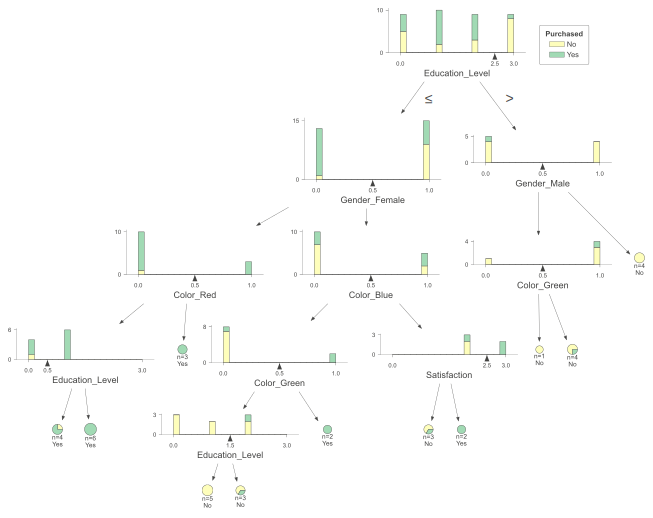

In [116]:
viz.view()

In [135]:
x_sample= df.sample(1)
x_sample

,Gender,Color,Education_Level,Satisfaction,Purchase
9,Male,Red,High School,Poor,1


In [136]:
x_sample= pipe.named_steps['pipe1'].transform(x_sample)

In [137]:
x_sample

array([[0., 0., 0., 1., 0., 0., 1., 0.]])

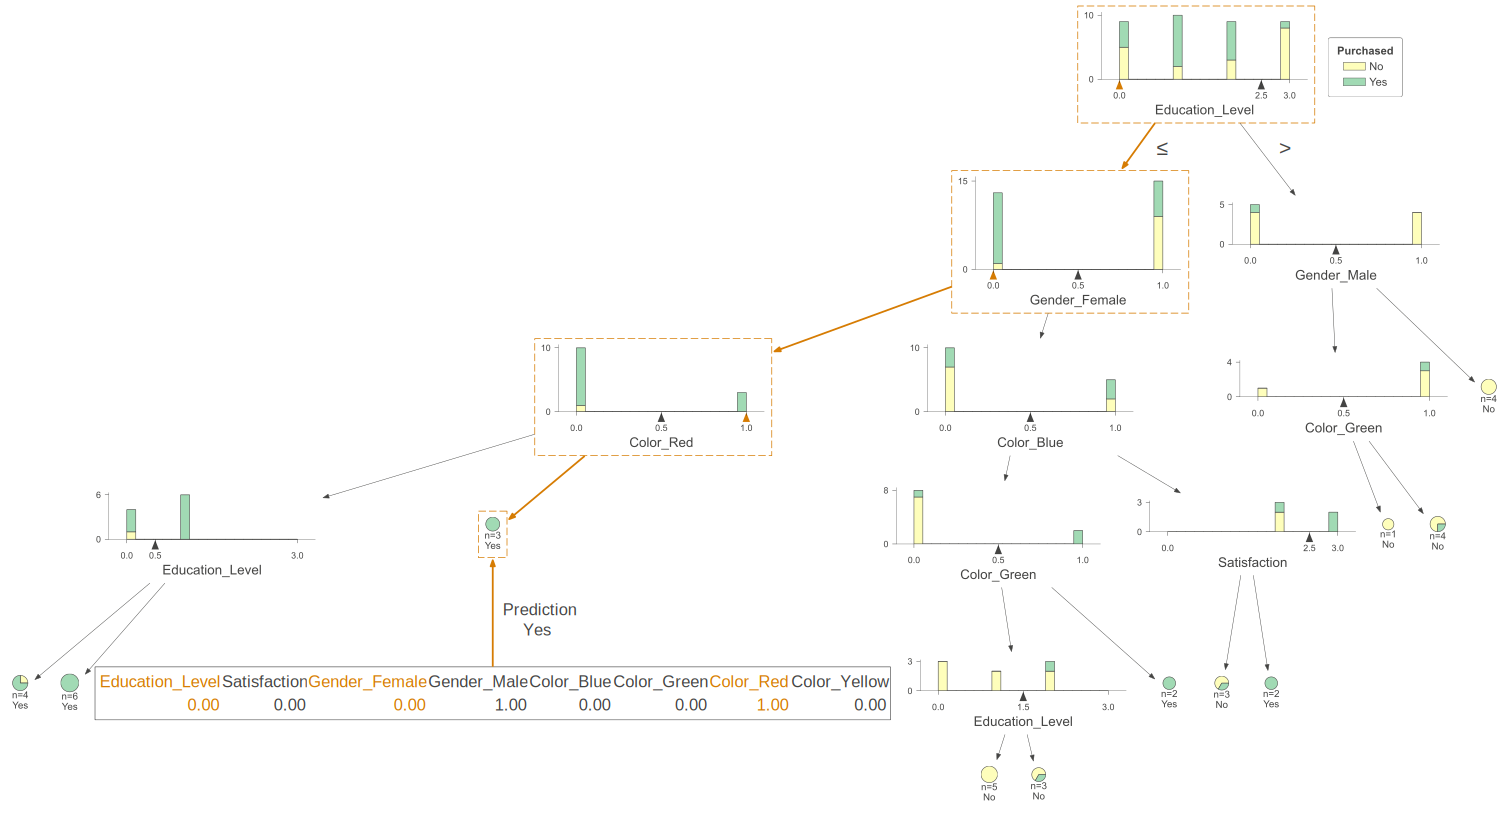

In [138]:
viz.view(x= x_sample.ravel(), scale= 1.5)